In [1]:
import torch

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import numpy as np
import joblib

/global/homes/b/brookluo/.local/perlmutter/pytorch2.0.1/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
from astropy.table import Table
import fitsio

In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src import decam_info

In [5]:
from inference import read_embeds

# Check the model performance

In [6]:
# load train data from last train
train_dir = Path("/pscratch/sd/b/brookluo/decam-exposure/dino_v2/base_resize_dr10cut/train")
train_data, train_idx, train_label = read_embeds(train_dir / "eval/embeds_out")
train_embeds = np.vstack(train_data) #[np.mean(it, axis=0) for it in train_data]) for five crop instead of resize

In [7]:
train_label = np.array(train_label, dtype=int)

In [8]:
knnpl = joblib.load('/global/u1/b/brookluo/decam-exposure-quality/postproc/knn_pipe.pkl')

In [9]:
knnpl.score(train_embeds, train_label)

/global/homes/b/brookluo/.local/perlmutter/pytorch2.0.1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:219: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


0.0

In [10]:
y_pred_prob = knnpl.predict_proba(train_embeds)

pred_label = np.argmax(y_pred_prob, axis=1)
classes = knnpl.classes_
pred_label = np.array([classes[i] for i in pred_label], dtype=int)
y_prob = np.max(y_pred_prob, axis=1)

In [22]:
pick_thresh = y_prob > 0.8

In [23]:
train_label_cut = train_label[pick_thresh]
pred_label_cut = pred_label[pick_thresh]

In [24]:
def calculate_accuracy_per_class(y_true, y_pred):
    pick = y_true == 0
    score = sum(y_pred[pick] == y_true[pick]) / len(y_true[pick])
    num = 0
    label_name = ["0_good"]
    print(num, "good", score)
    for i, rea in enumerate(decam_info.reason_li, start=1):
        if sum(y_true==i) == 0:
            continue
        num += 1
        pick = y_true == i
        # score = knnpl.score(train_embeds[pick], train_label[pick])
        score = sum(y_pred[pick] == y_true[pick]) / len(y_true[pick])
        print(num, rea, score)
        label_name.append(f"{num}_{rea}")
    return label_name

In [25]:
label_name = calculate_accuracy_per_class(train_label_cut, pred_label_cut)

0 good 0.8911475409836066
1 Saturated 0.9864864864864865
2 Clouds_transparency 0.9785187560115421
3 PSF 0.9225806451612903
4 Nonoptimal_exp 0.9541284403669725
5 Ghost_Scatter 0.7965451055662188
6 NObjects 0.9443099273607748
7 Bad_CCD 0.9521484375
8 Noise 0.9923195084485407
9 Wonky 0.9196428571428571
10 Telescope_Moving 0.8617886178861789
11 Out_of_focus 0.9700598802395209


vit_base with resizing images
                       precision    recall  f1-score   support

               0_good       0.86      0.89      0.88      1525
          1_Saturated       0.96      0.99      0.97       370
2_Clouds_transparency       0.97      0.98      0.97      3119
                3_PSF       0.94      0.92      0.93      1550
     4_Nonoptimal_exp       0.94      0.95      0.95       763
      5_Ghost_Scatter       0.92      0.80      0.85      1042
           6_NObjects       0.88      0.94      0.91       826
            7_Bad_CCD       0.97      0.95      0.96      1024
              8_Noise       0.92      0.99      0.96       651
              9_Wonky       0.84      0.92      0.88       112
  10_Telescope_Moving       0.93      0.86      0.89       369
      11_Out_of_focus       0.98      0.97      0.97       835

             accuracy                           0.94     12186
            macro avg       0.93      0.93      0.93     12186
         weighted avg  

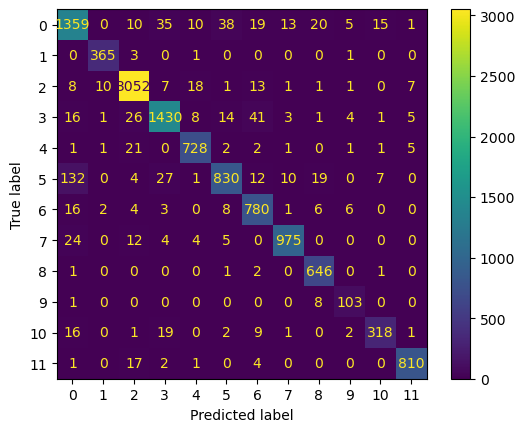

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_true=train_label_cut, y_pred=pred_label_cut)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
# plt.savefig(plot_dir / f"vit_base_confusion_pretrain.png")
print("vit_base with resizing images")
print(classification_report(train_label_cut, pred_label_cut, target_names=label_name))

# Do inference on the DR11 images

In [6]:
root_dir = Path("/pscratch/sd/b/brookluo/decam-exposure/dr11")

In [7]:
dr11_imdir = Path("/global/cfs/cdirs/cosmo/work/legacysurvey/dr11/images")

In [8]:
dr11_tab = pd.read_csv(root_dir / "data/good_exp_20ccd_decam_dr11.csv")

In [10]:
data_dir = root_dir / "proc-data"
path_tmpl = "/pscratch/sd/b/brookluo/decam-exposure/dr11/node{}/embeds_out"
outdir = Path("/pscratch/sd/b/brookluo/decam-exposure/dr11/inference")

In [29]:
def get_label_proba(model, X):
    y_pred_prob = model.predict_proba(X)
    y_pred = np.argmax(y_pred_prob, axis=1)
    pred_prob = np.max(y_pred_prob, axis=1)
    # convert from model class to data class
    pred_label = np.array([model.classes_[i] for i in y_pred], dtype=int)
    return pred_label, pred_prob

In [30]:
get_label_proba(knnpl, train_embeds)

(array([ 5, 15, 15, ...,  0,  0,  0]),
 array([0.57142857, 0.57142857, 0.71428571, ..., 0.85714286, 0.85714286,
        0.85714286]))

In [95]:
# first check if all embeds have been generated
# name = f'idx_{orig_idx:d}_label_{onelab.item():d}'
for i in range(16):
    df = pd.read_csv(data_dir / f"node{i}_dr11_sample.csv")
    pred_class = np.full(len(df), fill_value=-1, dtype=int)
    pred_prob = np.full(len(df), fill_value=-1, dtype=float)
    # data, idx, label = read_embeds(path_tmpl.format(i))
    print(i)
    data, idx, label = read_embeds(path_tmpl.format(i))
    data = np.vstack(data)
    idx = np.array(idx, dtype=int)
    #[np.mean(it, axis=0) for it in train_data]) for five crop instead of resize
    y_pred, y_proba = get_label_proba(knnpl, data)
    pred_class[idx] = y_pred
    pred_prob[idx] = y_proba
    df["ml_label"] = pred_class
    df['ml_prob'] = pred_prob
    df.to_csv(outdir / f"node{i}_output.csv", index=False)
# miss some due to leftovers from splitting, now fixed
# remember to regenerate embeddings for the leftover exposures

0
1
3
4
5
6
7
8
9
10
11
12
13
14
15


In [150]:
# target_dir = Path(target_dir)
# data = []
# idx = []
# label = []
# for i in range(num):
#     with h5py.File(target_dir / f"{i}_worker_embeds.h5", 'r') as h5f:
#         dset = h5f["images"]
#         for it in dset:
#             data.append(np.array(dset[it]))
#             names = it.split("_")
#             if names[1] in idx:
#                 print("reptition:", num, num-1, "on idx:", idx)
#             idx.append(names[1])
#             label.append(names[-1])

In [103]:
df_list = []
for fp in outdir.glob("*.csv"):
    df_list.append(pd.read_csv(fp, index_col=0))

In [108]:
df_merge = pd.concat(df_list, ignore_index=True)

In [201]:
df_merge['ml_label']

0          0
1          0
2          7
3          0
4          7
          ..
4474975   -1
4474976   -1
4474977   -1
4474978   -1
4474979   -1
Name: ml_label, Length: 4474980, dtype: int64

In [205]:
df_merge.loc[df_merge['ml_label'] > 0, 'ml_label'] -= 1

In [206]:
np.unique(df_merge['ml_label'])

array([-1,  0,  1,  2,  4,  5,  6,  7,  8,  9, 12, 13, 14])

In [207]:
df_merge.to_csv(outdir / "merged_sample.csv", index=False)

In [11]:
df_merge = pd.read_csv(outdir / "merged_sample.csv")

In [12]:
pick_thresh = df_merge['ml_prob'] > 0.9
pick_bad = df_merge['ml_label'] > 0
# pick_class = df_merge['ml_label'] == 14
pick = pick_thresh & pick_bad #& pick_class

In [13]:
# first add a probablity cut
# then select top 200 bad exposures in each category
# this will overestimate the performance of the model

In [102]:
selected = df_merge[pick]

In [103]:
uni_exp, idx, counts = np.unique(selected['expnum'], return_counts=True, return_index=True)

In [104]:
exp_fnames = selected['image_filename'].iloc[idx]

In [105]:
sum(counts > 2)

4323

In [106]:
# sort_idx = np.argsort(counts)[::-1]
sort_idx = np.argsort(uni_exp)
uni_exp = uni_exp[sort_idx]
counts = counts[sort_idx]
exp_fnames = exp_fnames.to_numpy()[sort_idx]

In [108]:
with open(root_dir / "fnames_bad_exp_prob_gt_09_occur_gt_2.csv", 'w') as fh:
    for i in np.where(counts > 2)[0]:
        exp = uni_exp[i]
        fname = exp_fnames[i]
        fh.write(f"{exp},{fname}\n")

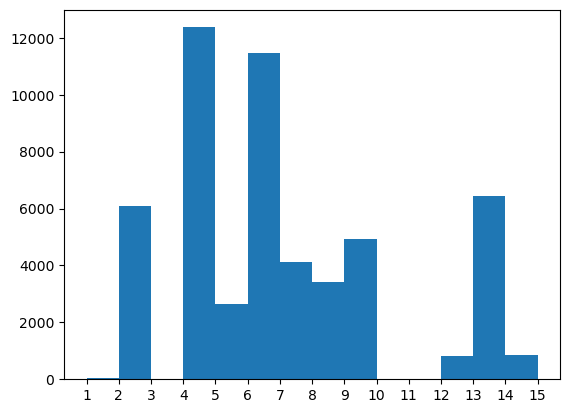

In [341]:
plt.hist(selected['ml_label'], bins=np.arange(1, 16, 1))
plt.xticks(np.arange(1, 16, 1))
plt.show()

In [299]:
import fitsio
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from plot_utils import plot_zscale_image

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                            2
image_hdu                                                         2
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631142, dtype: object


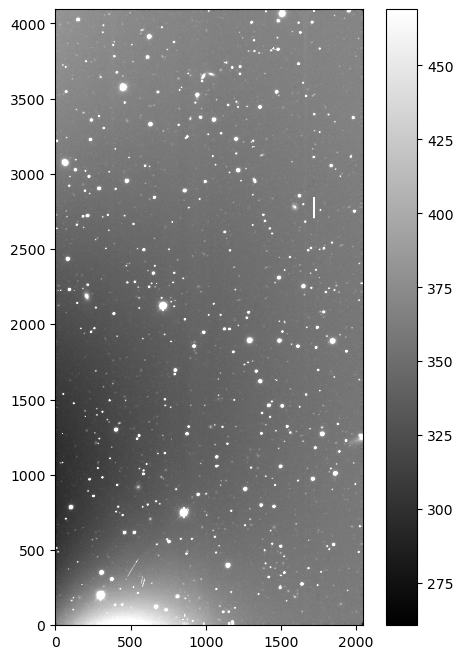

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                            8
image_hdu                                                         8
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631144, dtype: object


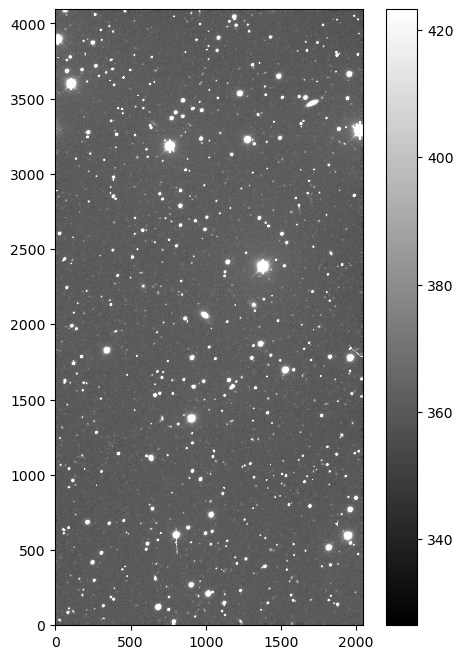

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           10
image_hdu                                                        10
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631145, dtype: object


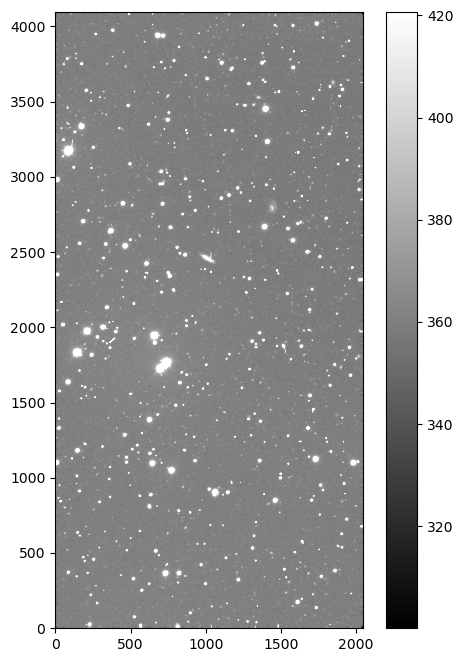

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           15
image_hdu                                                        15
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631146, dtype: object


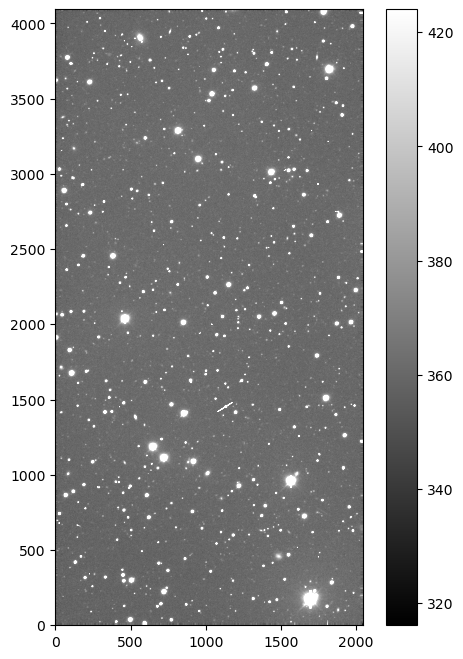

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           22
image_hdu                                                        22
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631147, dtype: object


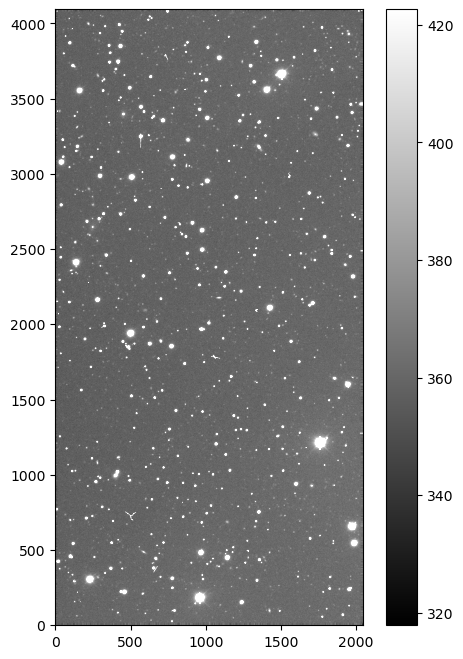

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           23
image_hdu                                                        23
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631148, dtype: object


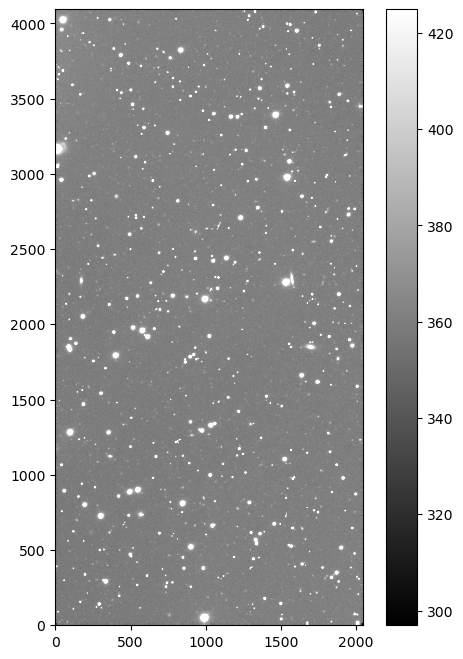

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           30
image_hdu                                                        30
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631151, dtype: object


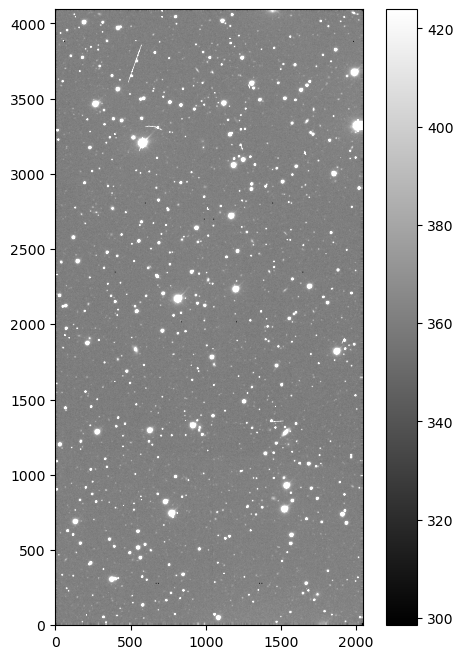

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           37
image_hdu                                                        37
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631153, dtype: object


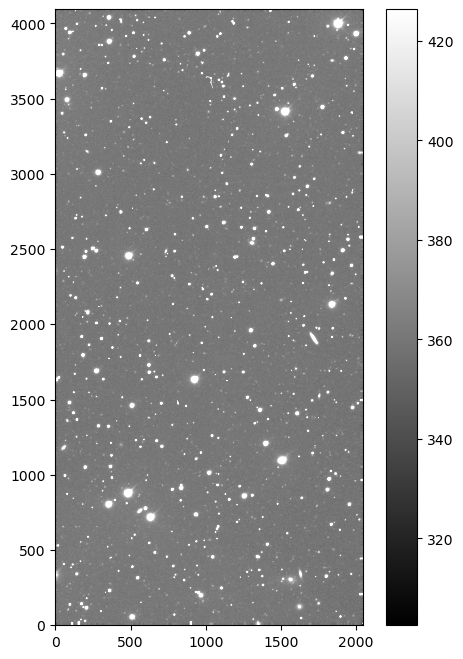

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           42
image_hdu                                                        42
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631155, dtype: object


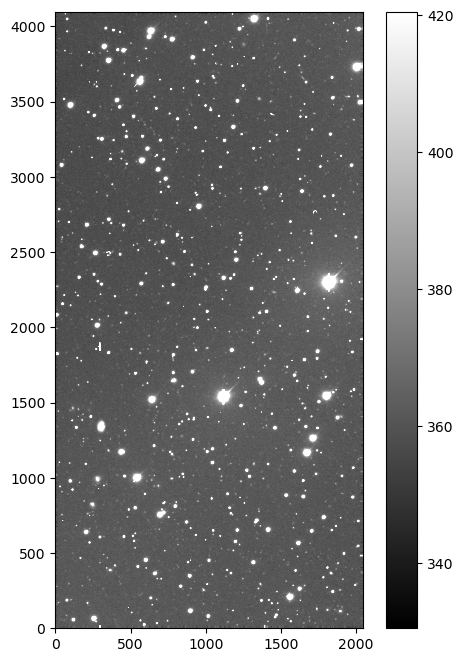

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           46
image_hdu                                                        46
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631156, dtype: object


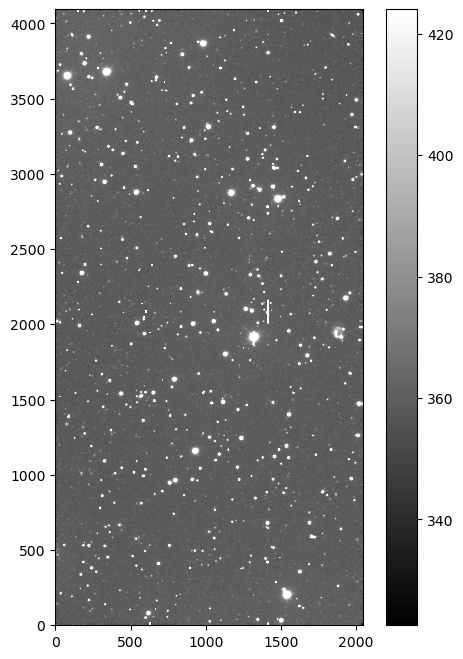

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           56
image_hdu                                                        56
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631158, dtype: object


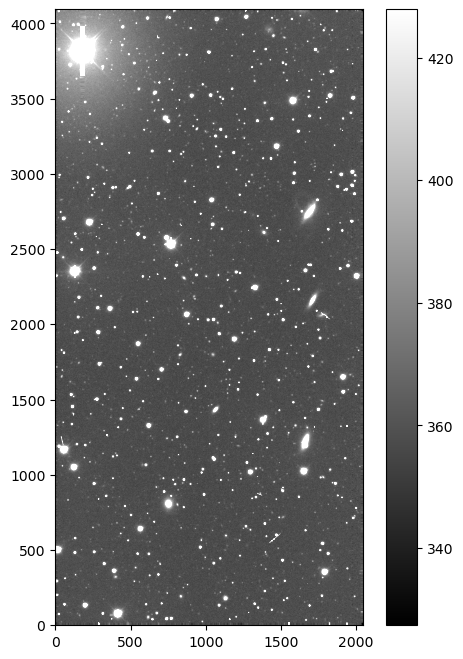

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           58
image_hdu                                                        58
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631159, dtype: object


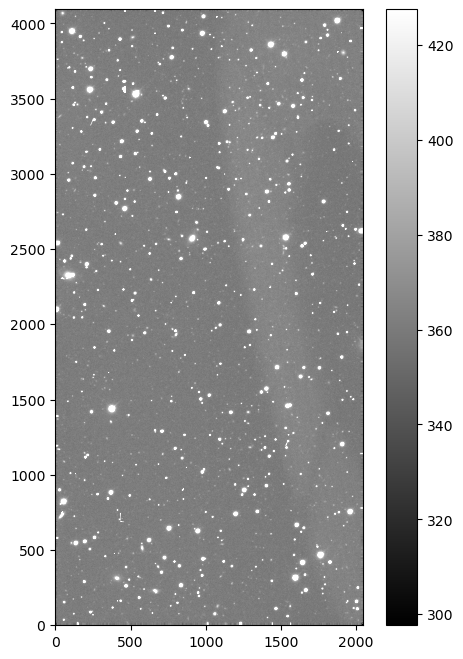

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           59
image_hdu                                                        59
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631160, dtype: object


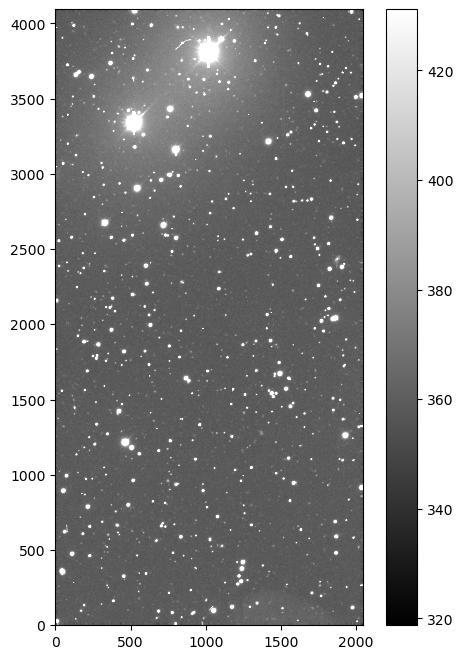

image_filename    decam/DECam_CP-DR11/CP20230614/c4d_230615_0442...
expnum                                                      1214278
ccdnum                                                           60
image_hdu                                                        60
filter                                                            1
reasons                                                           0
vi_source                                                         0
ml_label                                                          6
ml_prob                                                         1.0
Name: 631161, dtype: object


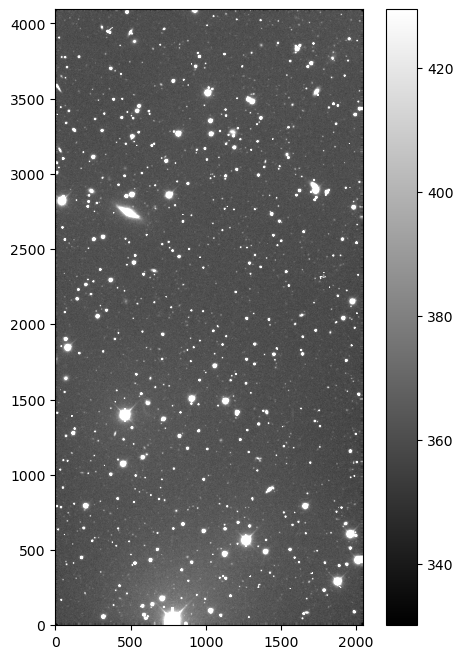

In [352]:
df_exp = selected.query("expnum == 1214278")
# plt.subplots()
for i, row in df_exp.iterrows():
    print(row)
    data = fitsio.read(dr11_imdir / row["image_filename"], ext=row['image_hdu'])
    fig, ax = plt.subplots(figsize=(6, 8))
    plot_zscale_image(data, ax, 'gray')
    plt.show()

In [306]:
np.unique(df_merge['expnum']).shape

(223749,)

In [310]:
uni_exp.shape[0] / np.unique(df_merge['expnum']).shape[0]

0.12914471126127938